In [18]:
import os
import torch
import numpy as np
import pyexr  # This will be our reliable loader
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [9]:
class KOREATECH_HolographyDataset(Dataset):
    def __init__(self, root_dir, encoder):
        self.encoder = encoder
        self.img_dir = os.path.join(root_dir, "img")
        self.depth_dir = os.path.join(root_dir, "depth")
        self.amp_dir = os.path.join(root_dir, "amp")
        self.phs_dir = os.path.join(root_dir, "phs")
        
        # Get all potential indices
        all_indices = sorted([f.replace(".exr", "") for f in os.listdir(self.img_dir) if f.endswith(".exr")])
        
        # Optional: You could pre-validate files here, but let's do it on-the-fly to save time
        self.indices = all_indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        
        # 1. Engineered Input (30 channels)
        x = self.encoder.encode(os.path.join(self.img_dir, f"{i}.exr"), 
                               os.path.join(self.depth_dir, f"{i}.exr"))
        
        # 2. Corrected Target Loading
        # Load Amplitude and Phase
        amp_raw = self.encoder.load_exr(os.path.join(self.amp_dir, f"{i}.exr"))
        phs_raw = self.encoder.load_exr(os.path.join(self.phs_dir, f"{i}.exr"))
        
        # Convert to Tensors and ensure [1, 512, 512]
        # pyexr/cv2 often returns [512, 512, 3] even for grayscale EXRs
        amp = torch.from_numpy(amp_raw)
        phs = torch.from_numpy(phs_raw)

        # Fix: Take only the first channel if it's 3-channel, and remove extra dims
        if amp.ndim == 3: amp = amp[:, :, 0] 
        if phs.ndim == 3: phs = phs[:, :, 0]
        
        # Final target stack [2, 512, 512]
        y = torch.cat([amp.unsqueeze(0), phs.unsqueeze(0)], dim=0)
            
        return x, y

In [10]:
# from huggingface_hub import snapshot_download

# # This will download ONLY the phs folder into your directory
# snapshot_download(
#     repo_id="SPIN-Lab/KOREATECH-CGH-512-3.6Mu",
#     repo_type="dataset",
#     local_dir=r"C:\Users\Kai Kumano\workspace\CGH-depth\dataset\KOREATECH-CGH-512-3.6Mu",
#     allow_patterns=["train/phs/*"]
# )
# print("Download complete!")

In [11]:
class KOREATECH_CGH_Encoder:
    def __init__(self, res=512, pitch=3.6e-6, wavelength=638e-9):
        self.res, self.pitch, self.wavelength = res, pitch, wavelength
        f = torch.fft.fftfreq(res, d=pitch)
        self.fy, self.fx = torch.meshgrid(f, f, indexing='ij')
        term = (1.0 / self.wavelength)**2 - self.fx**2 - self.fy**2
        self.phase_kernel_base = 2 * np.pi * torch.sqrt(torch.clamp(term, min=0))

    def load_exr(self, path):
        # pyexr loads directly into float32 numpy arrays 
        file = pyexr.open(path)
        return file.get().astype(np.float32)

    def encode(self, img_path, depth_path):
        rgb_raw = self.load_exr(img_path)
        depth_raw = self.load_exr(depth_path)

        # Correct shape for Torch [C, H, W]
        rgb = torch.from_numpy(rgb_raw).permute(2, 0, 1) if rgb_raw.ndim == 3 else torch.from_numpy(rgb_raw).unsqueeze(0)
        depth = torch.from_numpy(depth_raw).squeeze()
        
        # Physics: 20.33mm range
        z_map = depth * 20.3336e-3 
        encoding_arg = self.phase_kernel_base * z_map
        freq_cos, freq_sin = torch.cos(encoding_arg), torch.sin(encoding_arg)
        
        # 8 Depth Buckets (24 Channels)
        buckets = [rgb * ((depth >= i/8.0) & (depth < (i+1)/8.0)).float().unsqueeze(0) for i in range(8)]
            
        return torch.cat([rgb, depth.unsqueeze(0), freq_cos.unsqueeze(0), freq_sin.unsqueeze(0), *buckets], dim=0)

In [12]:
data_root = r"C:\Users\Kai Kumano\workspace\CGH-depth\dataset\KOREATECH-CGH-512-3.6Mu"
encoder = KOREATECH_CGH_Encoder()
train_dataset = KOREATECH_HolographyDataset(os.path.join(data_root, "train"), encoder)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)

try:
    x, y = next(iter(train_loader))
    print(f"Success Input Shape: {x.shape}, Target Shape: {y.shape}")
except Exception as e:
    print(f"Final Attempt Failed: {e}")

Success Input Shape: torch.Size([1, 30, 512, 512]), Target Shape: torch.Size([1, 2, 512, 512])


Model architecture (U-Net)

In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class SimpleUNet(nn.Module):
    def __init__(self, in_channels=30, out_channels=2):
        super(SimpleUNet, self).__init__()

        # Encoder (Downsampling)
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        
        # Bottleneck
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        # Decoder (Upsampling)
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(1024, 512)
        
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(512, 256)
        
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(256, 128)
        
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up4 = DoubleConv(128, 64)

        # Output Head: [Amplitude, Phase]
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # Decoder with Skip Connections
        u1 = self.up1(x5)
        u1 = torch.cat([u1, x4], dim=1)
        u1 = self.conv_up1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, x3], dim=1)
        u2 = self.conv_up2(u2)

        u3 = self.up3(u2)
        u3 = torch.cat([u3, x2], dim=1)
        u3 = self.conv_up3(u3)

        u4 = self.up4(u3)
        u4 = torch.cat([u4, x1], dim=1)
        u4 = self.conv_up4(u4)

        return self.outc(u4)

# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleUNet(in_channels=30, out_channels=2).to(device)
print(f"Model initialized on {device}")

Model initialized on cuda


Training model

In [14]:
import torch.optim as optim

# 1. Loss Function
# We use MSE to compare the predicted Amplitude/Phase with the Ground Truth
criterion = nn.MSELoss()

# 2. Optimizer
# Adam is generally best for U-Net architectures
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 3. Learning Rate Scheduler (Optional but recommended)
# This reduces the learning rate if the loss stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

num_epochs = 50  # Start with 50 and observe the loss curve

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to GPU
        inputs = inputs.to(device)   # [Batch, 30, 512, 512]
        targets = targets.to(device) # [Batch, 2, 512, 512]
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        
        # Calculate loss
        loss = criterion(outputs, targets)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if batch_idx % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{batch_idx}/{len(train_loader)}] Loss: {loss.item():.6f}")

    epoch_loss = running_loss / len(train_loader)
    print(f"==> Epoch {epoch+1} Complete. Average Loss: {epoch_loss:.6f}")
    
    # Update scheduler
    scheduler.step(epoch_loss)
    
    # Optional: Save the model every 10 epochs
    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f"unet_cgh_epoch_{epoch+1}.pth")

Epoch [1/50] Batch [0/5000] Loss: 0.395542
Epoch [1/50] Batch [10/5000] Loss: 0.250437
Epoch [1/50] Batch [20/5000] Loss: 0.172792
Epoch [1/50] Batch [30/5000] Loss: 0.104119
Epoch [1/50] Batch [40/5000] Loss: 0.056103
Epoch [1/50] Batch [50/5000] Loss: 0.086470
Epoch [1/50] Batch [60/5000] Loss: 0.039731
Epoch [1/50] Batch [70/5000] Loss: 0.023883
Epoch [1/50] Batch [80/5000] Loss: 0.026593
Epoch [1/50] Batch [90/5000] Loss: 0.020241
Epoch [1/50] Batch [100/5000] Loss: 0.018570
Epoch [1/50] Batch [110/5000] Loss: 0.019047
Epoch [1/50] Batch [120/5000] Loss: 0.020673
Epoch [1/50] Batch [130/5000] Loss: 0.014947
Epoch [1/50] Batch [140/5000] Loss: 0.014716
Epoch [1/50] Batch [150/5000] Loss: 0.016571
Epoch [1/50] Batch [160/5000] Loss: 0.016981
Epoch [1/50] Batch [170/5000] Loss: 0.011078
Epoch [1/50] Batch [180/5000] Loss: 0.013327
Epoch [1/50] Batch [190/5000] Loss: 0.012890
Epoch [1/50] Batch [200/5000] Loss: 0.011310
Epoch [1/50] Batch [210/5000] Loss: 0.015519
Epoch [1/50] Batch [2

Model Prediction

In [25]:
model_path = "unet_cgh_epoch_20.pth" # Your 30-channel model weights
data_root = r"C:\Users\Kai Kumano\workspace\CGH-depth\dataset\KOREATECH-CGH-512-3.6Mu"
save_dir = r"C:\Users\Kai Kumano\workspace\CGH-depth\results\engineered_predictions"
os.makedirs(save_dir, exist_ok=True)

# 2. LOAD MODEL (30-Channel Architecture)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the 30-channel U-Net
model = SimpleUNet(in_channels=30, out_channels=2).to(device)

# Load the trained weights
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# 3. INITIALIZE ENCODER
# Ensure this matches the parameters used during training
encoder = KOREATECH_CGH_Encoder(res=512, pitch=3.6e-6, wavelength=638e-9)

# 4. SELECT TEST SAMPLE
test_index = "5500" 
test_img_path = os.path.join(data_root, "test", "img", f"{test_index}.exr")
test_depth_path = os.path.join(data_root, "test", "depth", f"{test_index}.exr")

In [26]:
def predict_and_save_engineered():
    # A. Engineering the 30-channel input
    # This automatically handles RGB-D loading and diffraction math
    x_feature = encoder.encode(test_img_path, test_depth_path)
    
    # Add batch dimension and move to device: [1, 30, 512, 512]
    x_input = x_feature.unsqueeze(0).to(device)

    # B. Inference
    with torch.no_grad():
        output = model(x_input).squeeze(0).cpu().numpy() # [2, 512, 512]
    
    pred_amp = output[0]
    pred_phs = output[1]

    # C. Save to File (.exr)
    # Channel 0: Amplitude, Channel 1: Phase
    output_to_save = np.zeros((512, 512, 3), dtype=np.float32)
    output_to_save[:, :, 0] = pred_amp
    output_to_save[:, :, 1] = pred_phs

    save_path = os.path.join(save_dir, f"engineered_pred_{test_index}.exr")
    pyexr.write(save_path, output_to_save)
    print(f"Success! Engineered prediction saved to: {save_path}")

    return pred_amp, pred_phs

Success! Engineered prediction saved to: C:\Users\Kai Kumano\workspace\CGH-depth\results\engineered_predictions\engineered_pred_5500.exr


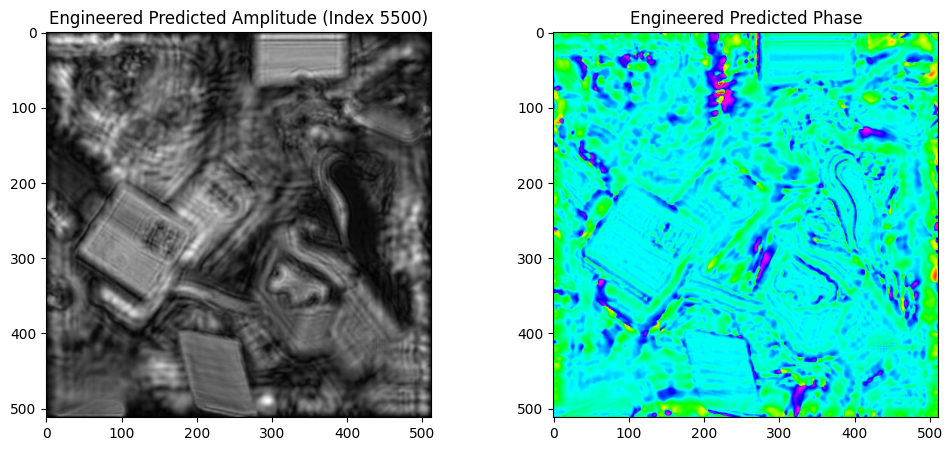

In [27]:
p_amp, p_phs = predict_and_save_engineered()

# 6. VISUALIZE IN JUPYTER
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(p_amp, cmap='gray')
axes[0].set_title(f"Engineered Predicted Amplitude (Index {test_index})")
axes[1].imshow(p_phs, cmap='hsv')
axes[1].set_title("Engineered Predicted Phase")
plt.show()